# Backpropagation

Algoritmo usado en Redes Neuronales Artificiales (ANN) clásicas del estilo Feed-Forward. Es una técnica ampliamente usada para entrenar redes neuronales profundas. 

Objetivos: 
1. Saber cómo un input se propaga hacia delante para calcular el output
2. Cómo propagar el error hacia atrás y entrenar la Red. 
3. Cómo aplicar el algoritmo de Backpropagation a modelos predictivos del mundo real. 

# Algoritmo de Backpropagation

Es un método de aprendizaje supervisado para ANN feed-forward multicapas. 

Feed-Forward se inspira en cómo procesan la info las neuronas (acepta señale de input a través de dendritas, luego pasa la señal vía un estímulo eléctrico a alguna celula del cuero). 

El principio de enfoque de Backpropagation es modelar una función dada a través de modificar pesos internos de las señales de los inputs y producir una señal de salida esperada. El sistema es entrenado usando un método de aprendizaje supervisado, donde el error entre el output del sistema y un output conocido es presentado al sistema y usado para modificar el estado interno de los pesos. 

Técnicamente el algoritmo de backpropagation es un método para entrenar pesos en una red neuronal feed-forward multicapa. Necesitamos que una estructura de red neuronal se defina de una o más capas donde una capa está completamente conectada a la siguiente. Una Estructura Estándar de Red es Una Capa de Input, Una Capa Oculta y Una Capa de Output. 

Backpropagation puede ser usado para problemas de clasificación y/o regresión. En este ejercicio veremos clasificación

En problemas de clasificación, los mejores resultados se alcanzan cuando la red tiene una neurona en la capa de salida para cada clase. Por ejemplo, un problema de clasificación binario (2 clases) con clase A y B. Estos outputs esperados tendrán que ser transformados en un vector binario como [1,0] y [0,1] (One Hot Encoder). 


Vamos a dividirlo en 6 partes: 
1. Inicializar la Red Neuronal
2. Propagar hacia delante (Feed-Forward)
3. **Backpropagation** Propagar el Errror hacia atrás.
4. Entrenar
5. Predecir
6. Tarea 3 (Aplica Backpropagation con una Base de Datos ). 

# 1. Inicializar la Red

Cada neurona tiene un conjunto de pesos que tienen que ser entrenados. Un peso por cada conexión y un peso adicional para su bias/sesgo (estilo constante en regresión lineal). 

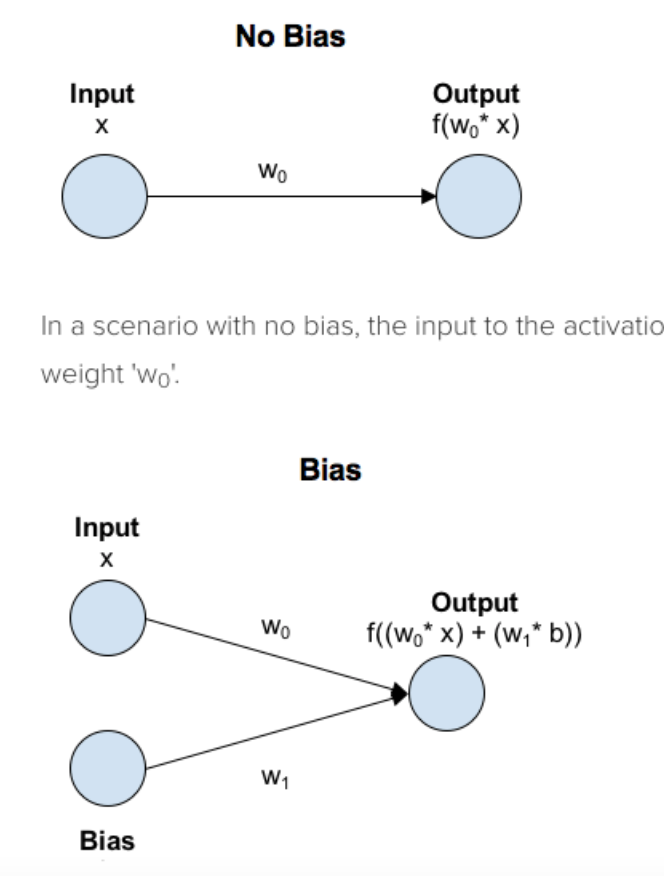

Durante el entrenamiento vamos ir guardando diferentes propiedades para cada neurona (por ejemplo su error asociado), por lo que usaremos un diccionario para representar cada neurona y guardar sus propiedades por nombres como `weights` para representar los pesos asociados en dicha neurona. 

Una Red neuornal está organizada por capas. La capa de entrada sólo es una fila de nuestra de base de entrenamiento, por lo que la primera verdadera capa es la capa oculta. Luego le sigue la capa de salida que tiene una neurona por cada una de las clases. 

Vamos a organizar las capas como un arreglo de diccionarios y tratar toda la Red como un arreglo de capas ..

Se recomienda iniciar los pesos de la red con números aleatorios en el rango 0 a 1. 

Primero crearemos una función que hace la red lista para entrenar con 3 parámetros: número de inputs, número de neuronas para tener en la capa oculta y un número de outputs. 

Para la capa oculta creamos `n_hidden` neuronas y cada neurona en esa capa tendrá `n_inputs` + 1 peso adicional, una para cada columna en el dataset y uno adicional para el bias. 

De igual forma la capa de salida que se conecta a la capa oculta tiene `n_outputs` neuronas, cada una con `n_hidden` + 1 peso adicional. Lo que significa que cada neurona en el output se conecta (tiene un peso) para cada neurona en la capa oculta. 

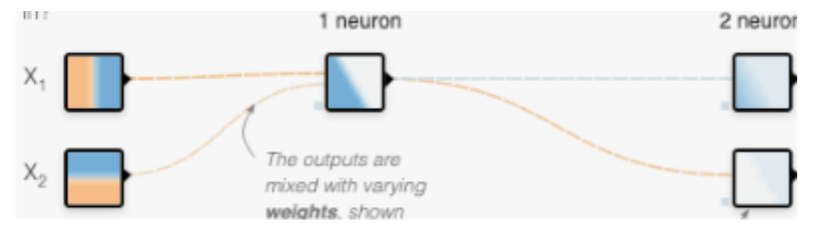

In [1]:
from random import seed,random

In [2]:
#Inicializar la Red
#n_hidden: el número de neuronas en la ÚNICA capa oculta. 

def initialize_network(n_inputs,n_hidden,n_outputs):
    network=list()
    hidden_layer=[{"weights":[random() for i in range(n_inputs+1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    
    
    
    output_layer=[{"weights":[random() for i in range(n_hidden+1)]} for i in range(n_outputs)]
    network.append(output_layer)
    
    return network

In [3]:
seed(1)
network=initialize_network(2,1,2)
for layer in network:
    print(layer)

[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614]}]
[{'weights': [0.2550690257394217, 0.49543508709194095]}, {'weights': [0.4494910647887381, 0.651592972722763]}]


In [78]:
seed(1)
network=initialize_network(2,5,2)
for layer in network:
    print(layer)

[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614]}, {'weights': [0.2550690257394217, 0.49543508709194095, 0.4494910647887381]}, {'weights': [0.651592972722763, 0.7887233511355132, 0.0938595867742349]}, {'weights': [0.02834747652200631, 0.8357651039198697, 0.43276706790505337]}, {'weights': [0.762280082457942, 0.0021060533511106927, 0.4453871940548014]}]
[{'weights': [0.7215400323407826, 0.22876222127045265, 0.9452706955539223, 0.9014274576114836, 0.030589983033553536, 0.0254458609934608]}, {'weights': [0.5414124727934966, 0.9391491627785106, 0.38120423768821243, 0.21659939713061338, 0.4221165755827173, 0.029040787574867943]}]


# 2. Propagar hacia delante(Feed-Forward)

Con la red iniciada podemos calcular un output a través de propagar una señal de input en cada una de las capas hasta llegar a los valores de salida (Feed-Forward)

Este método nos ayudará a corregir los pesos durante los entrenamiento y, una vez que esté entreanda la red, a hacer predicciones con nueva información. 

Vamos a descomponer forward propagation en tres partes: 

1. Operador Suma en la Neurona
2. Activación y Transferencia de Neurona
3. Propagación hacia delante. 

## 2.1 Operador Suma en la Neurona

Dado un input calcularemos la señal de entrada. El Input puede ser una fila de nuestro training data set para el caso de nuestra capa oculta. El Input También puede ser el mismo output de cada neurona en la capa oculta hacia la capa de salida. 

La suma ponderada de los inputs estilo regresión lineal. 

activation=sum(weight_i * input_i) + bias

Donde `weight`es el peso asociado en la red, `input` una fila de observaciones, `i` es el índice del peso asociados a cada input (columna del dataset). Y el `bias`es el peso especial que no tiene input que lo multiplique (se puede pensar como si el el input es siempre 1.0). 

Haremos una función que supone que el `bias` siempre es el último en la lista de pesos. 

In [4]:
#Calcular la Activación de las neuronas para los inputs

def activate(weights,inputs):
    #Iniciar con el Bias e ir sumando el producto punto de pesos en el input
    activation=weights[-1]*1
    for i in range(len(weights)-1):
        activation+=weights[i]*inputs[i]
    return activation

# 2.2 Activación y Transferencia de la Neurona

Ahora hay que activar y transferir el ouput de cada neurona. Usaremos la función sigmoidal: es una función que fácilmente podemos calcular su derivada (pendiente) cuando vemoas la propagación hacia atrás del error (back-propagation)

In [34]:
activate(network[0][0]['weights'],[1,1,None])

1.745572600026248

In [6]:
from math import exp

In [5]:
#Activar y Transferiar Outputs Neuronas
def transfer(activation):
    return 1.0/(1.0+exp(-activation))

# 2.3 Propagación hacia delante

Ahora propagaremos un input en toda la red para tener un ouput. Avanzaremos en cada capa de la red, calculando outputs para cada neurona y el output de una capa se convierte en el input de otra. 

Haremos una función que almacene el valor de ouput de cada neurona con el nombre `output` en el diccionario. Los outputs de la capa oculta los juntaremos como `new_inputs` que se convertirán en los inputs de la capa de salida. La función arrojará también los outputs finales de la capa de salida. 

In [7]:
network

[[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614]}],
 [{'weights': [0.2550690257394217, 0.49543508709194095]},
  {'weights': [0.4494910647887381, 0.651592972722763]}]]

In [8]:
#Forward propagation de un Input para un Output de la Red
def forward_propagate(network,row):
    inputs=row
    for layer in network:
        new_inputs=[]
        for neuron in layer: 
            #suma ponderada
            activation=activate(neuron["weights"],inputs)
            #función sigmoidal
            neuron["output"]=transfer(activation)
            new_inputs.append(neuron["output"])
        inputs=new_inputs
    return inputs

In [9]:
for layer in network: 
    print(layer)

[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614]}]
[{'weights': [0.2550690257394217, 0.49543508709194095]}, {'weights': [0.4494910647887381, 0.651592972722763]}]


In [10]:
row=[1,0,None]

In [11]:
row

[1, 0, None]

In [12]:
output=forward_propagate(network,row)
output

[0.6629970129852887, 0.7253160725279748]

In [63]:
[0,1]

[0, 1]

In [61]:
output[0]-[0,1][0]

0.6629970129852887

In [62]:
output[1]-[0,1][1]

-0.2746839274720252

In [13]:
network

[[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614],
   'output': 0.7105668883115941}],
 [{'weights': [0.2550690257394217, 0.49543508709194095],
   'output': 0.6629970129852887},
  {'weights': [0.4494910647887381, 0.651592972722763],
   'output': 0.7253160725279748}]]

Probaremos nuestra función con una capa oculta (1 neurona) que espera 2 valores de inputs y una capa de salida con dos neuronas. 

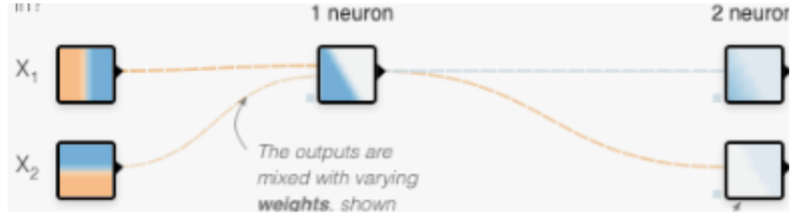

El ejemplo propaga el input [1,0] y produce un output. Debido a que el output tiene dos neuronas, tenemos una lista de 2 números como output. Lo que arroja son estilo de intensidades/probas para cada clase. Ahora no tiene mucho sentido lo que arroja, después veremos cómo entrenar los pesos con el método de Backpropagation

# 3. Backpropagation

El algoritmo de backpropagation es nombrado por la forma en que los pesos son entrenados. 

El error es calculado entre los ouputs esperados (y true) y los outputs propagados (y gorro) hacia delante de la red. Estos errores luego son propagados hacia atrás a través de la red desde el output de salida a la capa oculta, **asignando la culpa del  error a cada neurona** y actualizando los pesos en cada iteración. 

Esta parte lo veremos en dos secciones: 
1. Derivada de la Función de Activación 
2. Propagación del Error

## 3.1 Derivada de la Función de Activación

Dado un valor de salida de cada neurona necesitamos calcular su derivda/pendiente. La derivada nos dice el cambio en nuestro ouput ante cambio en los pesos. En nuestro ejercicio la función de activación que estamos usando es la sigmoidal, la derivda puede ser calculada como: 


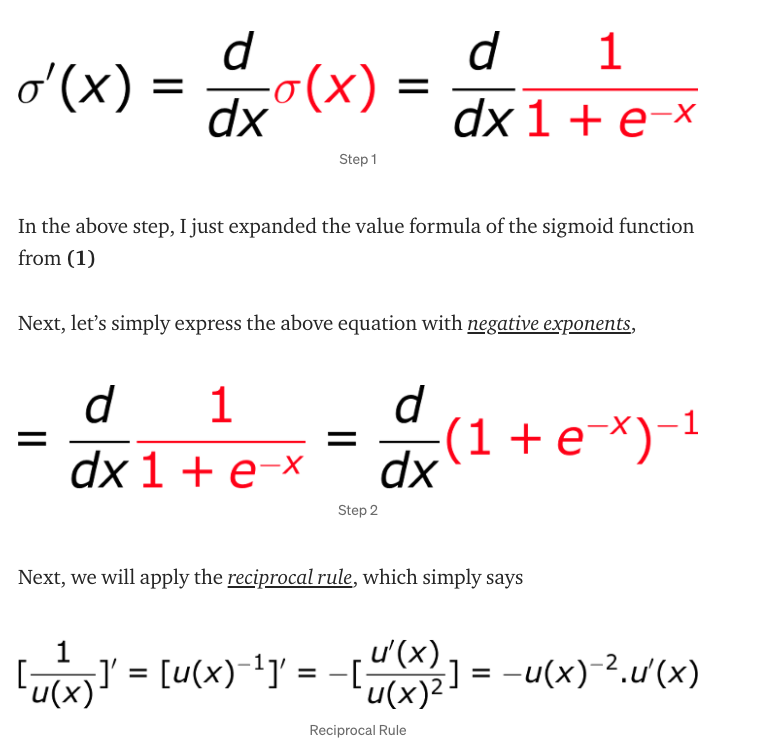


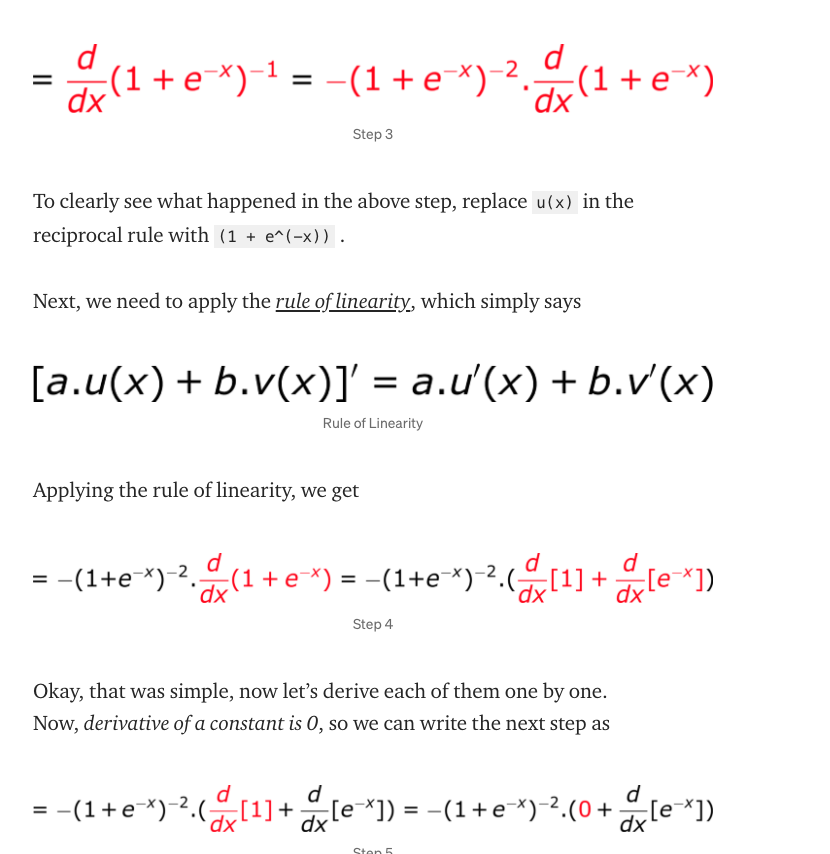

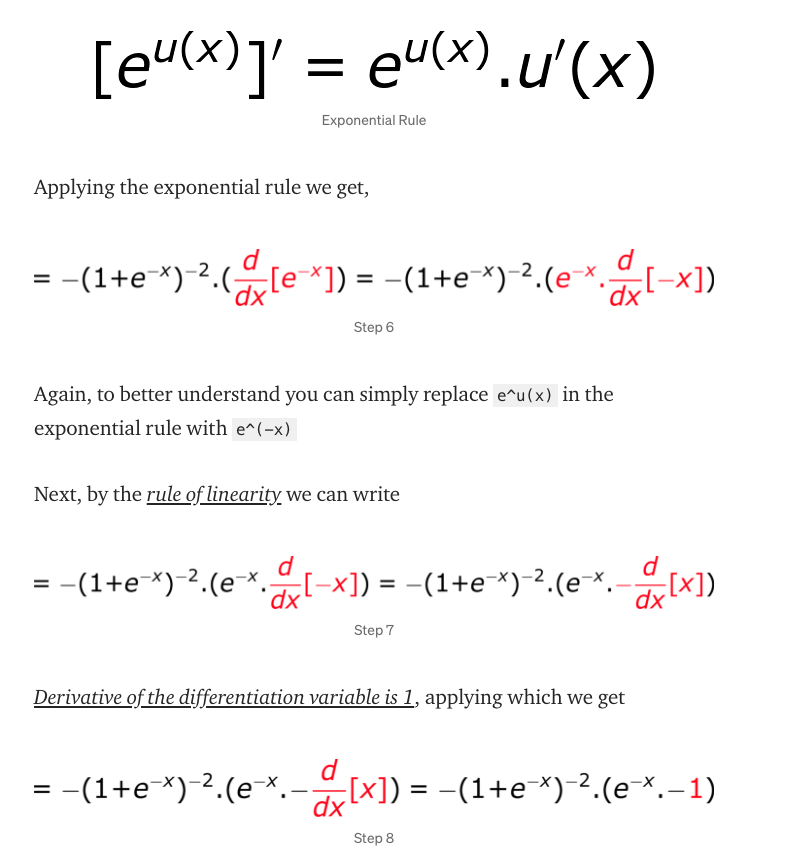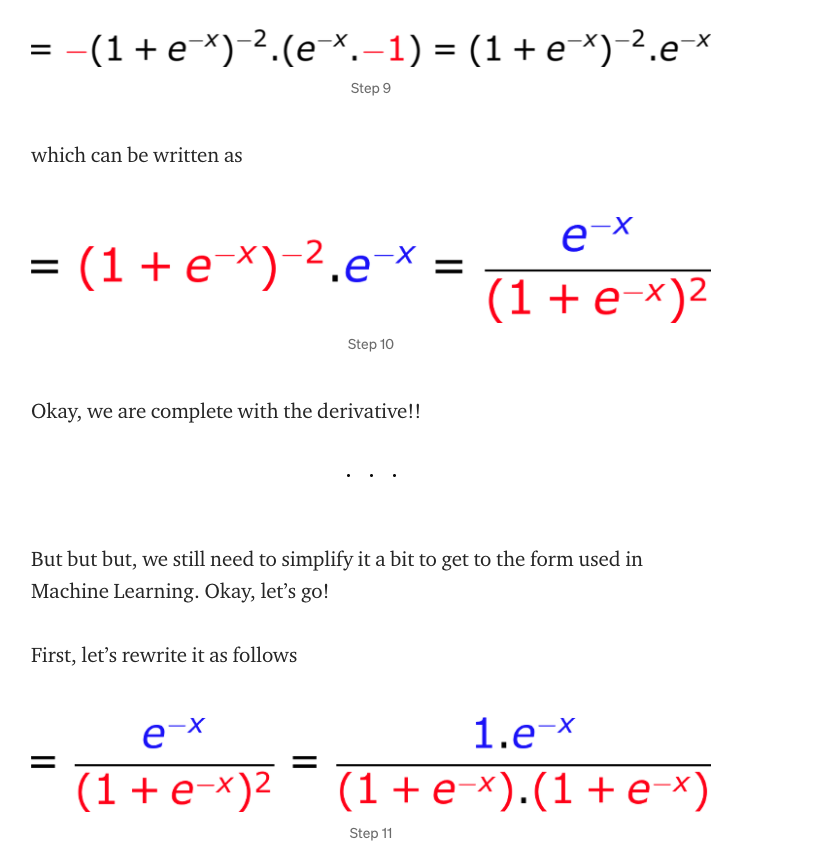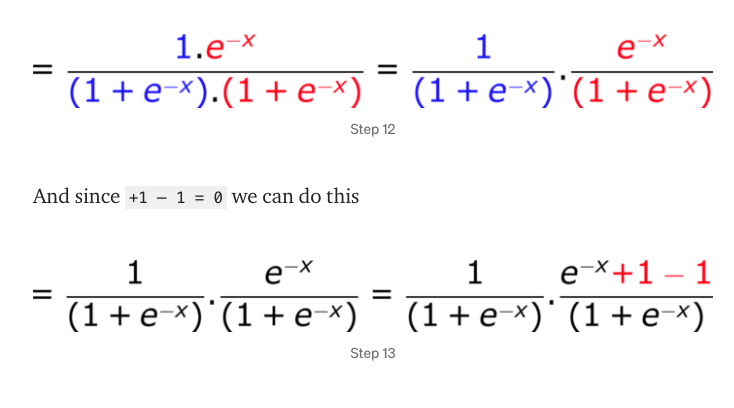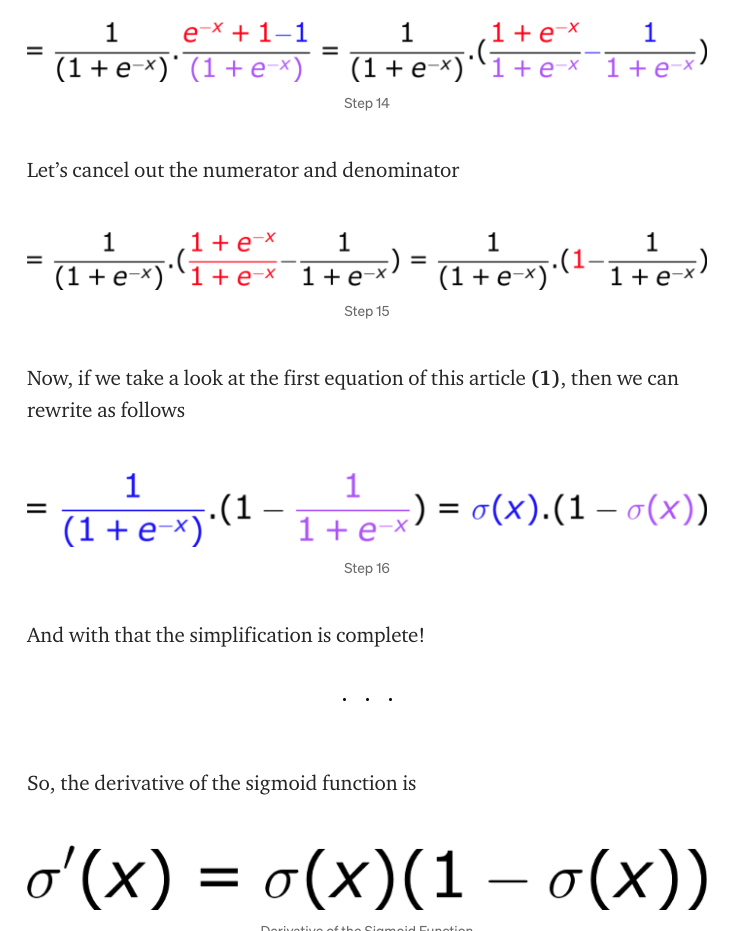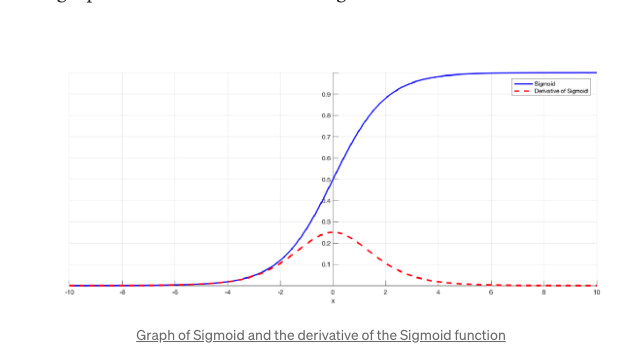

In [14]:
#Calcular la derivada para el output de la neurona. 
def transfer_derivative(output):
    return output*(1.0-output)

# 3.2 Propagación del Error

El primer paso es calulr el error para cada una de las neuronas de salida, esto dará la señal del error, la cual se propagará hacia através a través de la derivada. 

El error para una neurona dad puede ser calculado de la siguiente forma: 

error=(expected-output) * derivada_función_activación(output)

Expected es el valor de salida de y_train (y_true). Output es el ouput a través de Feed-Forward (y_gorro)

derivada_función_activación: calcula la pendiente del valor de salida para esa neurona. 

Este calcula del error es usado para las neurona de la capa output. Expected es literal el valor de y_test por clase (y_true)

La señal de error para neuronas en la capa oculta es calculada como el error ponderado para cada neurona en la capa de salida. Es válido vermo como el error viajando hacia atrás a través de los pesos de la capa salida a las neuronas de la capa oculta. 

La señal de error propagada hacia atrás es acumuluada y luego usado para determinar el error para cada neurona en la capa oculta. 

error=(weight_k * error_j) * transfer_derivative(output)

Donde el error_j es la señal de erro de la j-ésima neurona en el ouput de salida, weight_k es el peso que conecta la k-ésima neurona con la neurona actual y el output es el output para la neurona actual. 

Vamos a calcular la señal de error para cada neurona y almacenarla en el diccionario con el nombre de `delta`. Se van a iterar las capas de la Red en orden inverso para empezar con el output y trabajar hacia atrá. Asi nos aseguramos que las neuronas en la capa de salida tengan valores de `delta` calculados primero y que las neuronas en la capa oculta puedas usar esos valores en interaciones subsecuentes. Delta representa el cambio que el error implica en la neurona. 

La señal de error en las neuronas en la capa oculta son acumuladas de las neuronas en la capa de salida. Donde la neurona j-ésima es también el índice del peso de la neurona de en la capa salida. 

Los valores de los errores son calculos y almacenados en las neuronas para la capa de salida y la capa oculta

In [15]:
network

[[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614],
   'output': 0.7105668883115941}],
 [{'weights': [0.2550690257394217, 0.49543508709194095],
   'output': 0.6629970129852887},
  {'weights': [0.4494910647887381, 0.651592972722763],
   'output': 0.7253160725279748}]]

In [16]:
len(network)

2

In [17]:
list(range(len([1,2])))

[0, 1]

In [18]:
list(reversed(range(len([1,2]))))

[1, 0]

In [19]:
network[0]

[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614],
  'output': 0.7105668883115941}]

In [20]:
len(network[0])

1

In [21]:
layer=network[1]

In [22]:
range(len(layer))

range(0, 2)

In [23]:
#Propagar hacia atrás el error y almacernalo en las neuronas
#Expected: significa y_true

def backward_propagate_error(network,expected):
    
    for i in reversed(range(len([1,2]))):
        layer=network[i]
        errors=list()
        
        #Caso 1: Cuando no es la última capa
        #Cuando sí es la capa oculta
        if i!=len(network)-1:  #en la primera iteración si 1!=1 false
        #en la segunda iteración va a ser 0!=1 True (esto entra en la segunda iteración)
            for j in range(len(layer)):
                error=0.0
                for neuron in network[i+1]: #aquí llamamos al error en la capa siguiente
                #llamamos a delta de la última capa
                    error+=(neuron["weights"][j] * neuron["delta"])
                errors.append(error)
    
        
        #Caso 2: Cuando sí es la última capa oculta. 
        #Siempre que es 1 se viene aquí
        #La primer pregunta que hace arriba de 1!=1 False y se viene aquí
        else: 
            for j in range(len(layer)): #Vemos cuantas neuronas tenemos
                neuron=layer[j]
                errors.append(expected[j]-neuron["output"]) #y_true - y_gorro
        
        
        #Algo que aplicara para las dos capas: multiplicar por la derivada
        for j in range(len(layer)):
            neuron=layer[j]
            neuron["delta"]=errors[j]*transfer_derivative(neuron["output"])
    
    
    
    
    

In [24]:
network

[[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614],
   'output': 0.7105668883115941}],
 [{'weights': [0.2550690257394217, 0.49543508709194095],
   'output': 0.6629970129852887},
  {'weights': [0.4494910647887381, 0.651592972722763],
   'output': 0.7253160725279748}]]

In [25]:
#y_true
expected=[0,1]

In [26]:
backward_propagate_error(network,expected)

In [27]:
for layer in network: 
    print(layer)

[{'weights': [0.13436424411240122, 0.8474337369372327, 0.763774618976614], 'output': 0.7105668883115941, 'delta': -0.002711797799238243}]
[{'weights': [0.2550690257394217, 0.49543508709194095], 'output': 0.6629970129852887, 'delta': -0.14813473120687762}, {'weights': [0.4494910647887381, 0.651592972722763], 'output': 0.7253160725279748, 'delta': 0.05472601157879688}]


# 4. Entrenamiento de la Red

La red se entrena usando descenso de gradiente estocástico online (fila por fila). Esto involucra múltiples iteraciones de exponer el train dataset a la red y para cada fila de la base de datos, hacer un forward propagation de los inputs, backpropagation de los errores y actualizar los pesos. 

1. Actualizar Pesos
2. Entrenar la Red

### 4.1 Actualizar Pesos
Una vez que los errores son calculados para cada neurona en la red a a través del método de backpropagation, pueden ser usados para actualizar los pesos. 

weight_new=weight_viejo + (learning_rate * error * input)

donde weight es un peso dado, learning_rate es un hiperparámetros, error es calculado por backpropagation y el input es valor que provocó el error. 

el mismo procedimiento puede ser utilizado para actualiar el peso del bias, sólo que no hay input o se puede suponer un valor fijo de 1. 

Learning_rate controla cuanto cambiar el peso para controlar también el error. usualmuente se prefieren tasas bajas para encontrontra un set de parámetros en todas las capas (+lento y +iteraciones) con el trade-off que si tomas tasas altas encuentras unos de manera más rápid y que tengan más error. 

Recordar que el input para la capa de salida es una colección de outputs para la capa oculta.

In [28]:
#Actualizar pesos con Descenso de Gradiente
#Vamos a suponer que en la última columna viene la variable respuesta
#lo que queremos pronosticar de y (y_true) valor está en la última columna

def update_weights(network,row,l_rate):
    for i in range(len(network)): #para cada capa
        #vamos a tomar todo hasta la última columna de nuestra fila de datos (traer x's)
        inputs=row[:-1]
        #Caso especial para la capa final donde el input es diferente
        if i!=0: #primera iteración 0!=0 va a ser false
        #entra hasta la segunda interación 1!=0
            inputs=[neuron["output"] for neuron in network[i-1]]
        
        #Caso para la capa oculta y la capa final en conjunto
        for neuron in network[i]:
            for j in range(len(inputs)):#cada flecha/peso dentro de la neurona
                neuron["weights"][j] += l_rate*neuron["delta"]*inputs[j]
            #bias
            neuron["weights"][-1] += l_rate*neuron["delta"]*1


# 4.2 Entrenar la Red

Ya vimos cómo actualizar los pesos de la red, ahora hay que ver cómo hacerlo de manera iterativa. La red se actualiza usando descenso de gradiente estocástico online. Esto implica que hay que hacer un loop para un número fijo de epochs y dentro de cada epoch actualizar cada fila (batch=1) del training dataset. Dado que las actualizaciones están hechas para cada fila, este tipo de aprendizaje se llama online. Si los errores fueran acumulados en todo el epoch antes de actualizar, sería un batch-learning o descenso de gradiente por batch. Si solo fueran, por ejemplo 32,sería mini-batch


A continuación haremos una función que haga el entrenamiento de arriba, con un training dataset, tasa de aprendizaje, número fijo de epochs y un número esperado outputs. 

El número esperado de outputs es usado para transformar los valores de las clases del training en one hot encoder. Así se puede hacer un match del vector binario de las clases y el output de la red para calcular el error de la capa de salida.

También en cada iteración del epoch, calcularemos MSE entre el output de la Red y el output Esperado. Esto es útil para saber qué tanto la red está aprendiendo en cada epoch. 

In [48]:
#dos columnas x y una columna y (la última)
dataset = [[2.7810836,2.550537003,0],
	[1.465489372,2.362125076,0],
	[3.396561688,4.400293529,0],
	[1.38807019,1.850220317,0],
	[3.06407232,3.005305973,0],
	[7.627531214,2.759262235,1],
	[5.332441248,2.088626775,1],
	[6.922596716,1.77106367,1],
	[8.675418651,-0.242068655,1],
	[7.673756466,3.508563011,1]]

In [49]:
dataset

[[2.7810836, 2.550537003, 0],
 [1.465489372, 2.362125076, 0],
 [3.396561688, 4.400293529, 0],
 [1.38807019, 1.850220317, 0],
 [3.06407232, 3.005305973, 0],
 [7.627531214, 2.759262235, 1],
 [5.332441248, 2.088626775, 1],
 [6.922596716, 1.77106367, 1],
 [8.675418651, -0.242068655, 1],
 [7.673756466, 3.508563011, 1]]

In [50]:
n_outputs=2

In [52]:
#Convertir la "y" en One Hot Encoder para calcular el error. 
#Le pongo un 1 a las categorías que quisiera resaltar. 
expected=[0 for i in range(n_outputs)]
expected

[0, 0]

In [54]:
#las categorías en donde está la última columna
dataset[0][-1]

0

In [ ]:
#voy a prender la indicadora de la categoría 0
expected[dataset[0][-1]]=1

expected

In [64]:
#Enternar la Red para un número fijo de epochs: 
def train_network(network,train,l_rate,n_epochs,n_outputs):
    for epoch in range(n_epochs):
        sum_error=0
        for row in train: 
            #forward propagation de una fila
            outputs=forward_propagate(network,row)
            
            #Auxiliar: One/Hot/Encoder
            expected=[0 for i in range(n_outputs)]
            expected[row[-1]]=1 #aquí prende indicadora. Aquí suponemos que hay 
            #una posición "0". Si tienen en "y" 1,2,3 habría que pasarlo a 0,1,2
            
            #Indicativo para cada epoch
            sum_error+=sum([(expected[i]-outputs[i])**2 for i in range(len(expected))])
            
            #Sigue propagar el error hacia atrás
            backward_propagate_error(network,expected)
            
            #actualizarmos los pesos
            update_weights(network,row,l_rate)
        
        print(">=epoch=%d,lrate=%.3f,error=%.3f"%(epoch,l_rate,sum_error))
            
            
    

### Ejercicio

Vamos a usar dos neurons en la capa oculta y que sea un problema de clasificación binario (dos neuronas en la capa de salida). Lo entrenaremos por 20 epochs con una tasa de 0.5(la cual es alta pero también sólo tenemos 10 observaciones)

In [66]:
dataset

[[2.7810836, 2.550537003, 0],
 [1.465489372, 2.362125076, 0],
 [3.396561688, 4.400293529, 0],
 [1.38807019, 1.850220317, 0],
 [3.06407232, 3.005305973, 0],
 [7.627531214, 2.759262235, 1],
 [5.332441248, 2.088626775, 1],
 [6.922596716, 1.77106367, 1],
 [8.675418651, -0.242068655, 1],
 [7.673756466, 3.508563011, 1]]

In [69]:
len(dataset[0])

3

In [68]:
n_inputs=len(dataset[0])-1  #estamos contando el número de columnas sin la "y"
n_inputs

2

In [71]:
n_outputs=len(set(row[-1] for row in dataset))
n_outputs

2

In [72]:
network=initialize_network(n_inputs,2,n_outputs)
network

[[{'weights': [0.7887233511355132, 0.0938595867742349, 0.02834747652200631]},
  {'weights': [0.8357651039198697, 0.43276706790505337, 0.762280082457942]}],
 [{'weights': [0.0021060533511106927, 0.4453871940548014, 0.7215400323407826]},
  {'weights': [0.22876222127045265, 0.9452706955539223, 0.9014274576114836]}]]

In [73]:
train_network(network,dataset,0.5,20,n_outputs)
for layer in network:
    print(layer)

>=epoch=0,lrate=0.500,error=6.772
>=epoch=1,lrate=0.500,error=5.934
>=epoch=2,lrate=0.500,error=5.561
>=epoch=3,lrate=0.500,error=5.427
>=epoch=4,lrate=0.500,error=5.375
>=epoch=5,lrate=0.500,error=5.346
>=epoch=6,lrate=0.500,error=5.320
>=epoch=7,lrate=0.500,error=5.289
>=epoch=8,lrate=0.500,error=5.243
>=epoch=9,lrate=0.500,error=5.167
>=epoch=10,lrate=0.500,error=5.037
>=epoch=11,lrate=0.500,error=4.843
>=epoch=12,lrate=0.500,error=4.619
>=epoch=13,lrate=0.500,error=4.378
>=epoch=14,lrate=0.500,error=4.112
>=epoch=15,lrate=0.500,error=3.825
>=epoch=16,lrate=0.500,error=3.530
>=epoch=17,lrate=0.500,error=3.236
>=epoch=18,lrate=0.500,error=2.954
>=epoch=19,lrate=0.500,error=2.691
[{'weights': [1.1150736105858396, -1.3744036810415425, -0.5025574372710625], 'output': 0.9483052263131478, 'delta': 0.00894071061629689}, {'weights': [0.7810655718182448, 0.3654092266825157, 0.7344762774557891], 'output': 0.9996681219747121, 'delta': -4.614097675520693e-06}]
[{'weights': [-1.9784516879586775,

# 5. Predict
Para hacer predicciones con una red entrenada sólo hay que propagar hacia delante los inputs. Los outputs serán las probabilidades de pertenecer a cada una de las clases. Podemos seleccionar la clase que tenga la mayor proba. 
La función que haremos regreserá el índice donde está la mayor proba. Supone que los valors de las clases se han convertido a enteros que inician en 0. 

In [74]:
def predict(network,row):
    outputs=forward_propagate(network,row)
    return outputs.index(max(outputs))

In [75]:
network

[[{'weights': [1.1150736105858396, -1.3744036810415425, -0.5025574372710625],
   'output': 0.9483052263131478,
   'delta': 0.00894071061629689},
  {'weights': [0.7810655718182448, 0.3654092266825157, 0.7344762774557891],
   'output': 0.9996681219747121,
   'delta': -4.614097675520693e-06}],
 [{'weights': [-1.9784516879586775, 0.15635388997337066, 0.6090186190934966],
   'output': 0.2616106513260506,
   'delta': -0.050535465145768003},
  {'weights': [1.3466780484272503, -0.04273514580170421, -0.3022815158913298],
   'output': 0.6984695418211642,
   'delta': 0.06350528184444393}]]

In [77]:
for row in dataset: 
    prediction=predict(network,row)
    print("Valor de Y_true=%d, El valor de la Pred=%d"%(row[-1],prediction))

Valor de Y_true=0, El valor de la Pred=0
Valor de Y_true=0, El valor de la Pred=0
Valor de Y_true=0, El valor de la Pred=0
Valor de Y_true=0, El valor de la Pred=0
Valor de Y_true=0, El valor de la Pred=0
Valor de Y_true=1, El valor de la Pred=1
Valor de Y_true=1, El valor de la Pred=1
Valor de Y_true=1, El valor de la Pred=1
Valor de Y_true=1, El valor de la Pred=1
Valor de Y_true=1, El valor de la Pred=1


# El Accuracy fue de 100%
En el training dataset

# Tarea 3

### Parte 1 (Como lo hicimos en este cuaderno)
Utilizar el dataset de Seeds (se los comparto)
1. Cargar la base de datos.
2. Utilizar una función para convertir cada columna a float (excepto la última porque viene categoría:y)
3. Utilizar otra función para convertir las clases a valors enteros que inicien en 0. Hay 3 clases en el dataset
4. Escalar cada columna con el máximo y mínimo de cada columna (MinMaxScaler)
5. Definir una nueva función para hacer un 5-folds cross-validation. Calcular el accuracy para cada fold. 
6. El modelo será una Red Neuronal (como se vio en este libro con diccionarios) que la entrenen y luego hagan una predicción en el data set (cross-validate)
7. Los parámetros del modelo serán learning_rate=.01,n_epochs=100, n_hidden=5 (5 neuronas en UNA sólo capa oculta) (los pueden cambiar si mejora el modelo en el cross-validate)

### Parte 2 (con las librerías de cuadernos pasado): 

Replicar el ejercicio de Keras para corroborar: pueden utilizar wrapper de Scikit-Learn de Keras / directamente keras / scikit-Learn módulo Redes Neuronales